# Data Exploration

In [1]:
import polars as pl

In [2]:
df_features = pl.read_parquet("data/sample_initial_100k_features.parquet")
df_clean = df_features.filter(pl.all_horizontal(pl.col("^.*_valid$")))  # valid features

In [6]:
df_labels = pl.read_parquet("data/sample_initial_100k.1L83.p2rank.1.parquet")

In [7]:
df_labels.drop(
    ["mode", "conformational_state_id", "site_id", "rmsd_lb", "rmsd_ub", "pose_pdbqt"]
)

id,affinity_kcal_mol
str,f64
"""ZINCi500001jxFG6""",-5.626
"""ZINCon00000p6GAh""",-8.605
"""ZINCpm000019Ui0P""",-6.768
"""ZINCit000001ySPn""",-7.108
"""ZINCgy000001qgZI""",-5.694
…,…
"""ZINCir00000c3BtS""",-5.53
"""ZINCoj00000zGUMq""",-7.273
"""ZINCqu000003Evc7""",-7.613


In [9]:
df_labels["affinity_kcal_mol"].describe()

statistic,value
str,f64
"""count""",96798.0
"""null_count""",0.0
"""mean""",-4.060989
"""std""",16.565403
"""min""",-9.299
"""25%""",-6.988
"""50%""",-6.427
"""75%""",-5.88
"""max""",246.194


In [11]:
df_clean = df_labels.filter(pl.col("affinity_kcal_mol") < 0)

df_clean["affinity_kcal_mol"].describe()

statistic,value
str,f64
"""count""",93725.0
"""null_count""",0.0
"""mean""",-6.469762
"""std""",0.822376
"""min""",-9.299
"""25%""",-7.007
"""50%""",-6.461
"""75%""",-5.937
"""max""",-0.007


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='affinity_kcal_mol', ylabel='Count'>

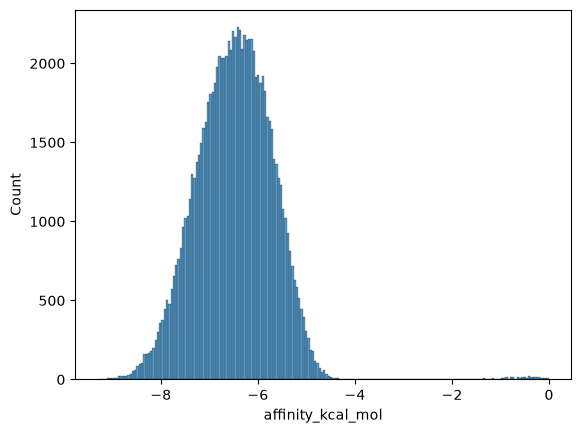

In [17]:
sns.histplot(data=df_clean, x="affinity_kcal_mol")